__Read FITS Files__

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

In [2]:
fits_files = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

images = [] 
headers = [] 

for file in fits_files:
    with fits.open(file) as hdul:
        header = hdul[0].header
        data = hdul[0].data
        headers.append(header)
        images.append(data)

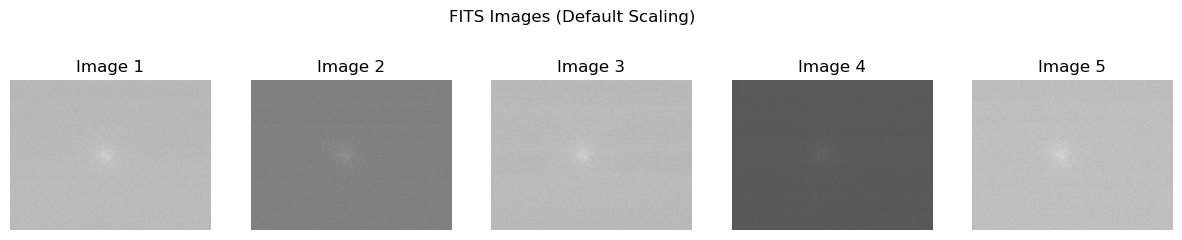

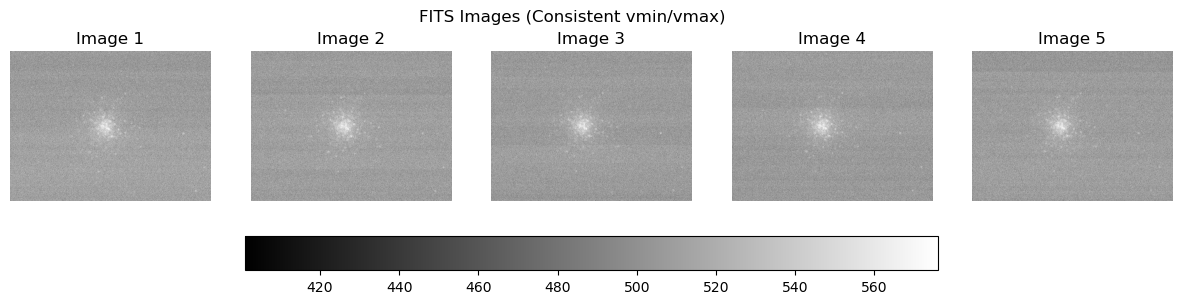

In [3]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(images[i], origin="lower", cmap="gray")
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

plt.suptitle("FITS Images (Default Scaling)")
plt.show()


all_pixels = np.concatenate([img.ravel() for img in images])
vmin, vmax = np.percentile(all_pixels, [1, 99])  # cut out extremes

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    im = axes[i].imshow(images[i], origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

fig.colorbar(im, ax=axes, orientation="horizontal")
plt.suptitle("FITS Images (Consistent vmin/vmax)")
plt.show()

With a consistent color scale, we can see the details of the images more clearly. As well as how the images themselves compare to each other since they are on the same color bar.

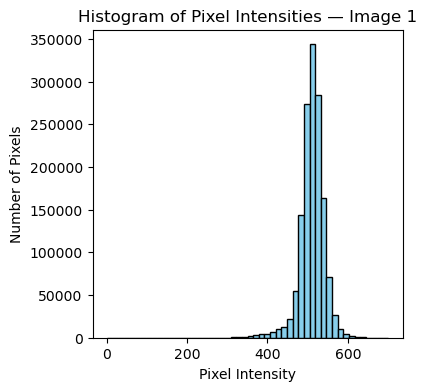

Image 1: mean = 510.471, median = 512.000, standard deviation = 30.3886


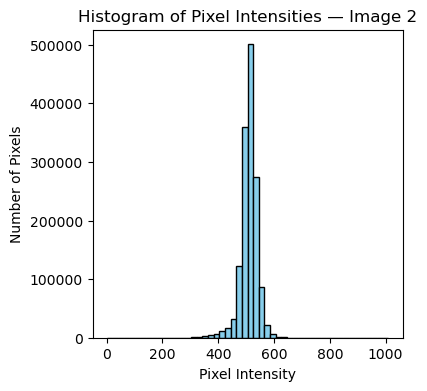

Image 2: mean = 509.746, median = 511.000, standard deviation = 30.2869


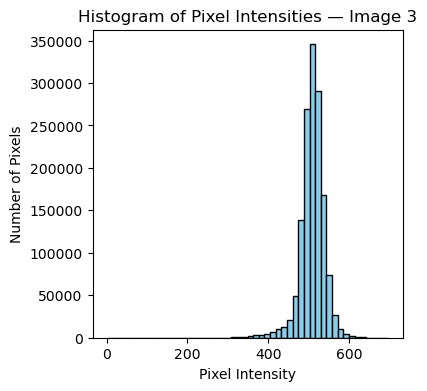

Image 3: mean = 508.050, median = 510.000, standard deviation = 30.1733


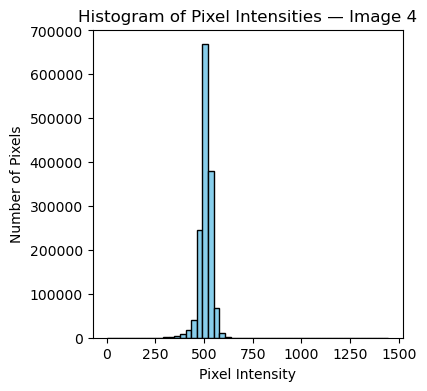

Image 4: mean = 507.906, median = 509.000, standard deviation = 30.1893


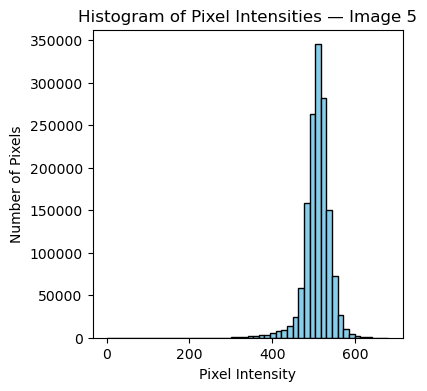

Image 5: mean = 508.792, median = 510.000, standard deviation = 30.1669


In [4]:
for i, data in enumerate(images):
    plt.figure(figsize=(4, 4))
    plt.hist(data.ravel(), bins=50, color="skyblue", edgecolor="black")
    plt.title(f"Histogram of Pixel Intensities — Image {i+1}")
    plt.xlabel("Pixel Intensity")
    plt.ylabel("Number of Pixels")
    plt.show()

    mean_val = np.mean(data)
    median_val = np.median(data)
    std_val = np.std(data)
    print(f"Image {i+1}: mean = {mean_val:.3f}, \
median = {median_val:.3f}, standard deviation = {std_val:.4f}")

- The x axis represents the intensity or the brightness of the pixel, while the y axis represents the number of pixels at that intensity/brightness.
- Bin=50 means that there are 50 discrete "bins" (the rectangular bars) that the pixel intensity can be placed into.
- Most of the data for each pixel intensity is centered around the 500 mark.
- The data doesn't seem to be spread out very much and stays relatively centered around the 500 mark.
- The median and mean pixel intensities have been printed beneath each histogram.

In [5]:
combined_image = np.median(images, axis=0)
print(f"Median pixel intensity = {np.median(combined_image):.3f}")

Median pixel intensity = 510.000


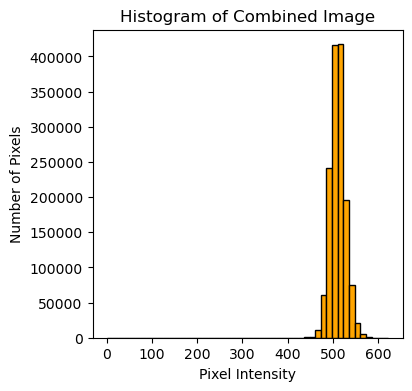

In [6]:
plt.figure(figsize=(4, 4))
plt.hist(combined_image.ravel(), bins=50, color="orange", edgecolor="black")
plt.title("Histogram of Combined Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.show()

Using vmin = 508.00, vmax = 512.00


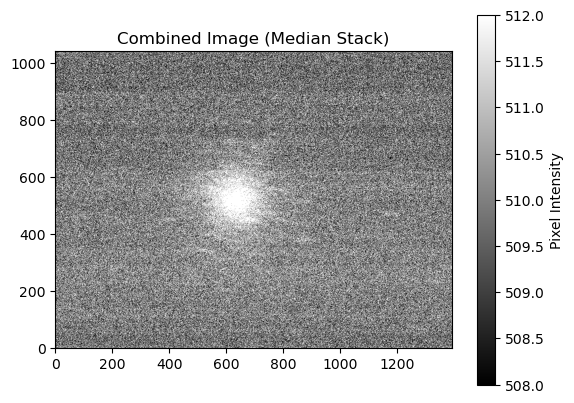

In [7]:
vmin, vmax = np.percentile(combined_image, [45, 55])
print(f"Using vmin = {vmin:.2f}, vmax = {vmax:.2f}")

# Plot the combined image
plt.imshow(combined_image, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Combined Image (Median Stack)")
plt.colorbar(label="Pixel Intensity")
plt.show()

This image shows the finer details and culmulative brightness more clearly than each image seperately. We can also see that there is less prominent horizontal lines going across the screen, so the noise seems to have been reduced (averaged out).

In [8]:
fits.writeto("combined.fits", combined_image, overwrite=True)

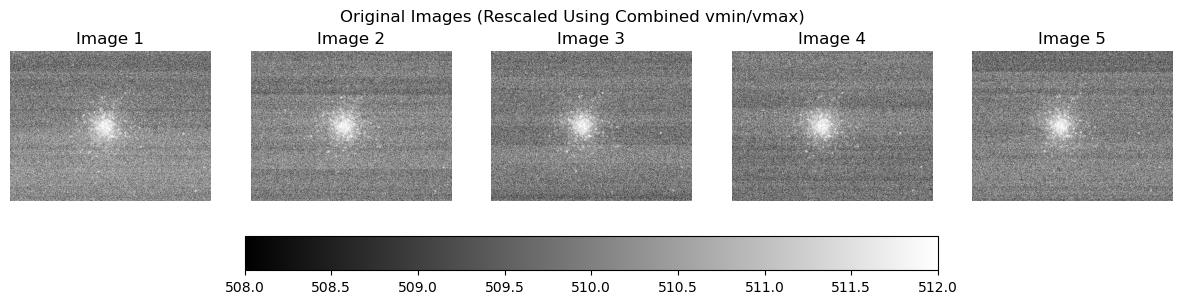

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    im = axes[i].imshow(images[i], origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
    axes[i].set_title(f"Image {i+1}")
    axes[i].axis("off")

fig.colorbar(im, ax=axes, orientation="horizontal")
plt.suptitle("Original Images (Rescaled Using Combined vmin/vmax)")
plt.show()